In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import gumbel_r
import pandas as pd
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import spearmanr, pearsonr
from glob import glob
from scipy.stats import ttest_ind,ranksums
import seaborn as sns
from collections import defaultdict

In [2]:
def get_performance(sRNA_id,genome_id,predicted_targets_path,
                    min_homolog=0,field='final score',hfq_weight=0.0,hfq_field = "hfq bg zscore",
                    id_extractor = lambda x:x.split(":")[1].split("-")[0],validated=False,excluded_protein_ids=None):
    known_targets_path = f"benchmark/leader/{genome_id}/{sRNA_id}.txt"
    if not os.path.exists(known_targets_path):
        return None,None
    if not os.path.exists(predicted_targets_path):
        return None,None
    known_targets = set()
    with open(known_targets_path) as f:
        for line in f:
            if validated and ("validated" not in line):
                continue
            protein_id = line.strip().split("\t")[0]
            known_targets.add(protein_id)
    if len(known_targets) <= 2:
        return None,None
    predictions = pd.read_csv(predicted_targets_path,sep="\t",index_col=0)
    
    if min_homolog > 0:
        predictions = predictions[predictions["homolog counts"] >= min_homolog]
    if excluded_protein_ids is not None:
        predictions = predictions[~predictions.index.isin(excluded_protein_ids)]
    if (field in ["sRNA zscore","pair zscore"]) and (hfq_field in predictions.columns):
        predictions["key"] = predictions[field]*(1-hfq_weight) + predictions[hfq_field]*hfq_weight
        field = "key"
    n = len(known_targets)
    predictions = predictions[~predictions.index.isna()]
    predictions = predictions[~(predictions.index=='na')]
    predictions.index = predictions.index.astype(str)
    predictions["is targets"] = predictions.index.map(lambda x:id_extractor(x) in known_targets)
    predictions = predictions.sort_values(by=field,ascending=False)
    recalls = predictions["is targets"].astype(int).cumsum().values[:500]
    return recalls, n


def get_intarna_performance(sRNA_ids,asm_id,params,validated=True,outdir="output/Enterobacteriaceae",excluded_protein_ids=None):
    total_recalls = np.zeros(500)
    N = 0
    for sRNA_id in sRNA_ids:    
        predicted_targets_path = f"{outdir}/{asm_id}/combined.final/{params}/{sRNA_id}.txt"  
        #print(predicted_targets_path,"##")
        recall, n = get_performance(sRNA_id,asm_id,predicted_targets_path,
                            min_homolog=0,field='sRNA zscore',hfq_weight=0.0,
                            id_extractor = lambda x:x.split(":")[1].split("-")[0],validated=validated,excluded_protein_ids=excluded_protein_ids)
        if recall is None:
            continue
        total_recalls += recall
        N += n
    total_recalls = total_recalls/N
    if total_recalls[0] != 0:
        total_recalls = [0] + list(total_recalls)
    return np.array(total_recalls)

def get_params_performance(sRNA_ids,asm_id,params,field="denoised score",validated=True,outdir="output/Enterobacteriaceae",
                           excluded_protein_ids=None):
    total_recalls = np.zeros(500)
    N = 0
    for sRNA_id in sRNA_ids:    
        predicted_targets_path = f"{outdir}/{asm_id}/combined.final/{params}/{sRNA_id}.txt"
        #print("#",predicted_targets_path)
        recall, n = get_performance(sRNA_id,asm_id,predicted_targets_path,
                            min_homolog=0,field=field,hfq_weight=0.0,hfq_field = "hfq bg zscore",
                            id_extractor = lambda x:x.split(":")[1].split("-")[0],validated=validated,excluded_protein_ids=excluded_protein_ids)
        if recall is None:
            continue
        total_recalls += recall
        N += n
    total_recalls = total_recalls/N
    if total_recalls[0] != 0:
        total_recalls = [0] + list(total_recalls)
    return np.array(total_recalls)

In [3]:
def get_copra_performance(sRNA_ids,asm_id,validated,outdir,excluded_protein_ids=None,field='score'):
    total_recalls = np.zeros(500)
    N = 0
    for sRNA_id in sRNA_ids:    
        predicted_targets_path = f"{outdir}/{asm_id}/{sRNA_id}.txt"
        recall, n = get_performance(sRNA_id,asm_id,predicted_targets_path,
                            min_homolog=0,field=field,id_extractor = lambda x:x,validated=validated,excluded_protein_ids=excluded_protein_ids)
        if recall is None:
            continue
        total_recalls += recall
        N += n
    total_recalls = total_recalls/N
    if total_recalls[0] != 0:
        total_recalls = [0] + list(total_recalls)
    return np.array(total_recalls)

In [5]:
def get_targetrna3_performance(sRNA_ids,asm_id,excluded_protein_ids=None):
    N = 0
    combined_recalls = np.zeros(500)    
    for sRNA_id in sRNA_ids:
        path = f"TargetRNA3/{asm_id}/{sRNA_id}.txt"
        if not os.path.exists(path):
            #print(f"skip {path} .")
            continue
        if asm_id == "GCF_000742755.1":
            validated = False
        else:
            validated = True
        recalls, n = get_performance(sRNA_id,asm_id,path,min_homolog=0,
                              field='Probability',id_extractor=lambda x:x,validated=validated,excluded_protein_ids=excluded_protein_ids)
        if recalls is None:
            continue
        combined_recalls += recalls
        N += n
        #print(sRNA_id, n)
    print(asm_id, N)  
    total_recalls = combined_recalls
    if total_recalls[0] != 0:
        total_recalls = [0] + list(total_recalls)
    return np.array(total_recalls)/N

In [6]:
def get_sRNARFTarget_performance(sRNA_ids,asm_id,excluded_protein_ids=None):
    N = 0
    combined_recalls = np.zeros(500)    
    for sRNA_id in sRNA_ids:
        path = f"sRNARFTarget/{asm_id}-{sRNA_id}.txt"
        if not os.path.exists(path):
            #print(f"skip {path} .")
            continue
        if asm_id == "GCF_000742755.1":
            validated = False
        else:
            validated = True
        recalls, n = get_performance(sRNA_id,asm_id,path,min_homolog=0,
                              field='scores',id_extractor=lambda x:x,validated=validated,excluded_protein_ids=excluded_protein_ids)
        if recalls is None:
            continue
        combined_recalls += recalls
        N += n
        #print(sRNA_id, n)
    print(asm_id, N) 
    total_recalls = combined_recalls
    total_recalls = total_recalls/N
    if total_recalls[0] != 0:
        total_recalls = [0] + list(total_recalls)
    return np.array(total_recalls)

In [7]:
sns.color_palette('deep')

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [8]:
color_lut = {"CMDTarget":"#4c72b0",
             "IntaRNA":"#dd8452",
             "CopraRNA":"#55a868",
             "TargetRNA3":"#c44e52",
             "sRNARFTarget":"#8172b3",
             "CMDTarget nohfq":"#937860"}

GCF_000006745.1 39
GCF_000006745.1 39


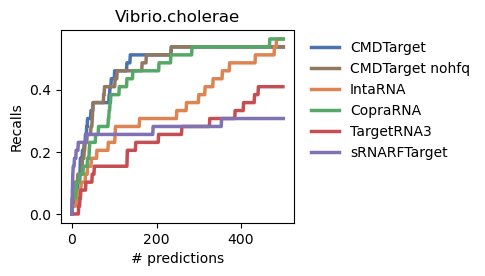

In [9]:
asm_id = "GCF_000006745.1"
validated = True
#ErsA.txt  NrsZ.txt  phrS.txt  prrF1.txt  prrF2.txt
sRNA_ids = ["MicV","Qrr1","VqmR","VrrA"]
species = "Vibrio.cholerae"
fig, ax = plt.subplots(figsize=(3,2.5))

params = f"hfq.200.100--{species}--pair.zscore-0.7_hfq.Z-0.3_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(recalls,label="CMDTarget",lw=2.5,color=color_lut["CMDTarget"])

params = f"wo.hfq--{species}--pair.zscore-1.0_hfq.Z-0.0_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(recalls,label="CMDTarget nohfq",lw=2.5,color=color_lut["CMDTarget nohfq"])

intarna_recalls = get_intarna_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(intarna_recalls,label="IntaRNA",lw=2.5,color=color_lut["IntaRNA"])

outdir = f"../comparative-sRNA-target-prediction/output/CopraRNA/{species}.by.genome"
copraRNA_recalls = get_copra_performance(sRNA_ids,asm_id,validated=validated,outdir=outdir)
ax.plot(copraRNA_recalls,label="CopraRNA",lw=2.5,color=color_lut["CopraRNA"])

targetrna3_recalls = get_targetrna3_performance(sRNA_ids,asm_id)
ax.plot(targetrna3_recalls,label="TargetRNA3",lw=2.5,color=color_lut["TargetRNA3"])

sRNARFTarget_recalls = get_sRNARFTarget_performance(sRNA_ids,asm_id)
ax.plot(sRNARFTarget_recalls,label="sRNARFTarget",lw=2.5,color=color_lut["sRNARFTarget"])

ax.set_xlabel("# predictions")
ax.set_ylabel("Recalls")
ax.set_title(species)
plt.legend(loc=(1.05,0.3),frameon=False)

GCF_000006765.1 25
GCF_000006765.1 25


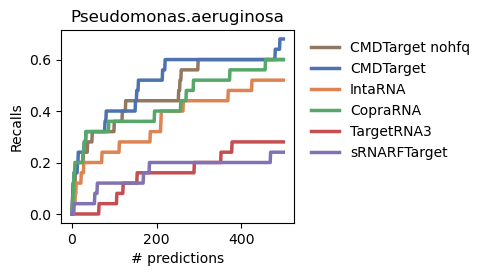

In [10]:
asm_id = "GCF_000006765.1"
validated = True
#ErsA.txt  NrsZ.txt  phrS.txt  prrF1.txt  prrF2.txt
sRNA_ids = ["ErsA","phrS","prrF1","PrrH"]
species = "Pseudomonas.aeruginosa"
fig, ax = plt.subplots(figsize=(3,2.5))

params = f"wo.hfq--{species}--pair.zscore-1.0_hfq.Z-0.0_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(recalls,label="CMDTarget nohfq",lw=2.5,color=color_lut["CMDTarget nohfq"])

params = f"hfq.200.100--{species}--pair.zscore-0.7_hfq.Z-0.3_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(recalls,label="CMDTarget",lw=2.5,color=color_lut["CMDTarget"])


intarna_recalls = get_intarna_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(intarna_recalls,label="IntaRNA",lw=2.5,color=color_lut["IntaRNA"])

outdir = f"../RNA-RNA-interaction/comparative-sRNA-target-prediction/output/CopraRNA/{species}.by.genome"
copraRNA_recalls = get_copra_performance(sRNA_ids,asm_id,validated=validated,outdir=outdir)
ax.plot(copraRNA_recalls,label="CopraRNA",lw=2.5,color=color_lut["CopraRNA"])

targetrna3_recalls = get_targetrna3_performance(sRNA_ids,asm_id)
ax.plot(targetrna3_recalls,label="TargetRNA3",lw=2.5,color=color_lut["TargetRNA3"])

sRNARFTarget_recalls = get_sRNARFTarget_performance(sRNA_ids,asm_id)
ax.plot(sRNARFTarget_recalls,label="sRNARFTarget",lw=2.5,color=color_lut["sRNARFTarget"])

ax.set_xlabel("# predictions")
ax.set_ylabel("Recalls")

ax.set_title(species)
plt.legend(loc=(1.05,0.3),frameon=False)

GCF_000092025.1 15
GCF_000092025.1 15


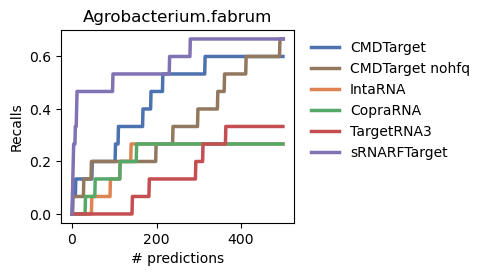

In [11]:
asm_id = "GCF_000092025.1"
#cat Agrobacterium.fabrum.sRNARFTarget.training.hits/hits.tsv | awk '$3==1{print $2"\t"$9"\t"$10}' | cut -f 2 -d ':' | bedtools intersect -loj -a - -b genomes/CDS/GCF_000092025.1.bed
exclude_protein_ids = None #open("benchmark/Agrobacterium.fabrum.sRNARFTarget.training.protein-ids.txt").read().strip().split("\n")
validated = True
species = "Agrobacterium.fabrum"
#ErsA.txt  NrsZ.txt  phrS.txt  prrF1.txt  prrF2.txt
sRNA_ids = ["AbcR1"]
fig, ax = plt.subplots(figsize=(3,2.5))

params = f"hfq.200.100--{species}--pair.zscore-0.7_hfq.Z-0.3_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}",excluded_protein_ids=exclude_protein_ids)
ax.plot(recalls,label="CMDTarget",lw=2.5,color=color_lut["CMDTarget"])

params = f"wo.hfq--{species}--pair.zscore-1.0_hfq.Z-0.0_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(recalls,label="CMDTarget nohfq",lw=2.5,color=color_lut["CMDTarget nohfq"])

intarna_recalls = get_intarna_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}",excluded_protein_ids=exclude_protein_ids)
ax.plot(intarna_recalls,label="IntaRNA",lw=2.5,color=color_lut["IntaRNA"])

outdir = f"../comparative-sRNA-target-prediction/output/CopraRNA/{species}.by.genome"
copraRNA_recalls = get_copra_performance(sRNA_ids,asm_id,validated=validated,outdir=outdir,excluded_protein_ids=exclude_protein_ids,field='raw-score')
ax.plot(copraRNA_recalls,label="CopraRNA",lw=2.5,color=color_lut["CopraRNA"])

targetrna3_recalls = get_targetrna3_performance(sRNA_ids,asm_id,excluded_protein_ids=exclude_protein_ids)
ax.plot(targetrna3_recalls,label="TargetRNA3",lw=2.5,color=color_lut["TargetRNA3"])

sRNARFTarget_recalls = get_sRNARFTarget_performance(sRNA_ids,asm_id,excluded_protein_ids=exclude_protein_ids)
ax.plot(sRNARFTarget_recalls,label="sRNARFTarget",lw=2.5,color=color_lut["sRNARFTarget"])


ax.set_xlabel("# predictions")
ax.set_ylabel("Recalls")
ax.set_title(species)
plt.legend(loc=(1.05,0.3),frameon=False)

In [12]:
copra_prediction = pd.read_csv('../RNA-RNA-interaction/comparative-sRNA-target-prediction/output/CopraRNA/Agrobacterium.fabrum.by.genome/GCF_000092025.1/AbcR1.txt',sep="\t")
validation_targets = pd.read_csv('benchmark/leader/GCF_000092025.1/AbcR1.txt',header=None,sep="\t")
validation_targets.columns = ["protein id","status"]
validation_targets = validation_targets.set_index('protein id')
exclude_protein_ids = open("benchmark/Agrobacterium.fabrum.sRNARFTarget.training.protein-ids.txt").read().strip().split("\n")

GCF_000013425.1 12
GCF_000013425.1 12


Text(0.5, 1.0, 'Staphylococcus.aureus')

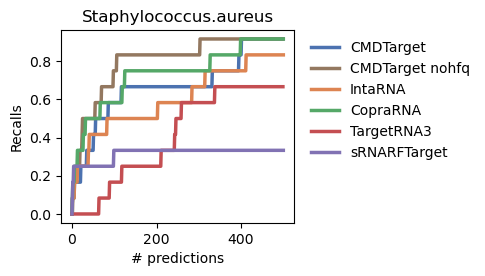

In [13]:
asm_id = "GCF_000013425.1"
validated = True
species = "Staphylococcus.aureus"
#ErsA.txt  NrsZ.txt  phrS.txt  prrF1.txt  prrF2.txt
sRNA_ids = ["RsaE","RsaA"]
fig, ax = plt.subplots(figsize=(3,2.5))

params = f"hfq.200.100--{species}--pair.zscore-0.7_hfq.Z-0.3_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(recalls,label="CMDTarget",lw=2.5,color=color_lut["CMDTarget"])

params = f"wo.hfq--{species}--pair.zscore-1.0_hfq.Z-0.0_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(recalls,label="CMDTarget nohfq",lw=2.5,color=color_lut["CMDTarget nohfq"])

intarna_recalls = get_intarna_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(intarna_recalls,label="IntaRNA",lw=2.5,color=color_lut["IntaRNA"])

outdir = f"../comparative-sRNA-target-prediction/output/CopraRNA/{species}.by.genome"
copraRNA_recalls = get_copra_performance(sRNA_ids,asm_id,validated=validated,outdir=outdir)
ax.plot(copraRNA_recalls,label="CopraRNA",lw=2.5,color=color_lut["CopraRNA"])

targetrna3_recalls = get_targetrna3_performance(sRNA_ids,asm_id)
ax.plot(targetrna3_recalls,label="TargetRNA3",lw=2.5,color=color_lut["TargetRNA3"])

sRNARFTarget_recalls = get_sRNARFTarget_performance(sRNA_ids,asm_id)
ax.plot(sRNARFTarget_recalls,label="sRNARFTarget",lw=2.5,color=color_lut["sRNARFTarget"])


ax.set_xlabel("# predictions")
ax.set_ylabel("Recalls")

plt.legend(loc=(1.05,0.3),frameon=False)
ax.set_title(species)

GCF_000009045.1 10
GCF_000009045.1 10


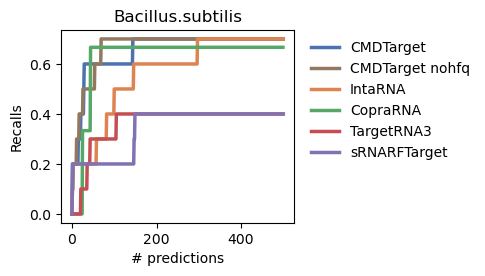

In [14]:
asm_id = "GCF_000009045.1"
validated = True
species = "Bacillus.subtilis"
sRNA_ids = ["FsrA","RoxS","SR1"]
fig, ax = plt.subplots(figsize=(3,2.5))

params = f"hfq.200.100--{species}--pair.zscore-0.7_hfq.Z-0.3_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(recalls,label="CMDTarget",lw=2.5,color=color_lut["CMDTarget"])

params = f"wo.hfq--{species}--pair.zscore-1.0_hfq.Z-0.0_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(recalls,label="CMDTarget nohfq",lw=2.5,color=color_lut["CMDTarget nohfq"])

intarna_recalls = get_intarna_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(intarna_recalls,label="IntaRNA",lw=2.5,color=color_lut["IntaRNA"])

outdir = f"../comparative-sRNA-target-prediction/output/CopraRNA/{species}.by.genome"
copraRNA_recalls = get_copra_performance(sRNA_ids,asm_id,validated=validated,outdir=outdir)
ax.plot(copraRNA_recalls,label="CopraRNA",lw=2.5,color=color_lut["CopraRNA"])


targetrna3_recalls = get_targetrna3_performance(sRNA_ids,asm_id)
ax.plot(targetrna3_recalls,label="TargetRNA3",lw=2.5,color=color_lut["TargetRNA3"])

sRNARFTarget_recalls = get_sRNARFTarget_performance(sRNA_ids,asm_id)
ax.plot(sRNARFTarget_recalls,label="sRNARFTarget",color=color_lut["sRNARFTarget"],lw=2.5)

ax.set_xlabel("# predictions")
ax.set_ylabel("Recalls")
ax.set_title(species)
plt.legend(loc=(1.05,0.3),frameon=False)

GCF_000009725.1 15
GCF_000009725.1 15


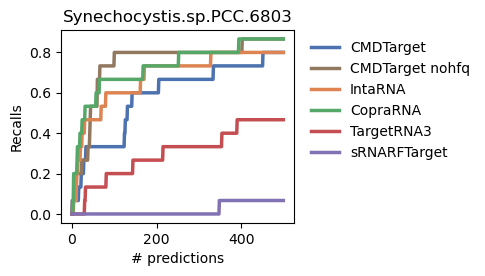

In [15]:
species = "Synechocystis.sp.PCC.6803"
asm_id = "GCF_000009725.1"
validated = True
sRNA_ids = ["IsaR1","PsrR1"]
fig, ax = plt.subplots(figsize=(3,2.5))

params = f"hfq.200.100--{species}--pair.zscore-0.7_hfq.Z-0.3_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(recalls,label="CMDTarget",lw=2.5,color=color_lut["CMDTarget"])

params = f"wo.hfq--{species}--pair.zscore-1.0_hfq.Z-0.0_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
recalls = get_params_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(recalls,label="CMDTarget nohfq",lw=2.5,color=color_lut["CMDTarget nohfq"])

intarna_recalls = get_intarna_performance(sRNA_ids,asm_id,params,validated=validated,outdir=f"output/{species}")
ax.plot(intarna_recalls,label="IntaRNA",lw=2.5,color=color_lut["IntaRNA"])

outdir = f"../comparative-sRNA-target-prediction/output/CopraRNA/{species}.by.genome"
copraRNA_recalls = get_copra_performance(sRNA_ids,asm_id,validated=validated,outdir=outdir)
ax.plot(copraRNA_recalls,label="CopraRNA",lw=2.5,color=color_lut["CopraRNA"])

targetrna3_recalls = get_targetrna3_performance(sRNA_ids,asm_id)
ax.plot(targetrna3_recalls,label="TargetRNA3",lw=2.5,color=color_lut["TargetRNA3"])

sRNARFTarget_recalls = get_sRNARFTarget_performance(sRNA_ids,asm_id)
ax.plot(sRNARFTarget_recalls,label="sRNARFTarget",lw=2.5,color=color_lut["sRNARFTarget"])

ax.set_xlabel("# predictions")
ax.set_ylabel("Recalls")
ax.set_title(species)

plt.legend(loc=(1.05,0.3),frameon=False)

In [16]:
import json

In [19]:
from copy import copy
TargetRNA3_recalls = {}
sRNA_ids_for_grid_search = open("/lulabdata/jinyunfan/CMDTarget/sRNA-ids.txt").read().strip().split("\n")
for genome_id in ["GCF_000005845.2","GCF_000210855.2","GCF_000742755.1","GCF_000006765.1","GCF_000006745.1"]:
    N = 0
    combined_recalls = np.zeros(500)    
    for sRNA_id in sRNA_ids_for_grid_search:
        path = f"../comparative-sRNA-target-prediction/output/TargetRNA3/{genome_id}/{sRNA_id}.txt"
        if not os.path.exists(path):
            #print(f"skip {path} .")
            continue
        if genome_id == "GCF_000742755.1":
            validated = False
        else:
            validated = True
        recalls, n = get_performance(sRNA_id,genome_id,path,min_homolog=0,
                              field='Probability',id_extractor=lambda x:x,validated=validated)
        if recalls is None:
            continue
        combined_recalls += recalls
        N += n
    combined_recalls = combined_recalls/N   
    TargetRNA3_recalls[genome_id] = copy(combined_recalls)    
from copy import copy
sRNARFTarget_recalls = {}
for genome_id in ["GCF_000005845.2","GCF_000210855.2","GCF_000742755.1"]:
    N = 0
    combined_recalls = np.zeros(500)    
    for sRNA_id in sRNA_ids_for_grid_search:
        path = f"sRNARFTarget/{genome_id}-{sRNA_id}.txt"
        if not os.path.exists(path):
            #print(f"skip {path} .")
            continue
        if genome_id == "GCF_000742755.1":
            validated = False
        else:
            validated = True
        recalls, n = get_performance(sRNA_id,genome_id,path,min_homolog=0,
                              field='scores',id_extractor=lambda x:x,validated=validated)
        if recalls is None:
            continue
        combined_recalls += recalls
        N += n
    combined_recalls = combined_recalls/N   
    sRNARFTarget_recalls[genome_id] = copy(combined_recalls)        

/BioII/lulab_b/jinyunfan/miniforge3/envs/rna-analysis/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in true_divide


In [20]:
used_sRNA_ids = set()
used_sRNA_ids_by_species = defaultdict(set)
n_validated_targets = pd.read_csv("validated-target-by-sepcies.txt",sep="\t")
counts = n_validated_targets[n_validated_targets["species"] == 'E. coli']
for sRNA_id in counts[counts["counts"] >= 3]["sRNA id"].values:
    used_sRNA_ids.add(sRNA_id)
    used_sRNA_ids_by_species["GCF_000005845.2"].add(sRNA_id)
    #print("GCF_000005845.2",sRNA_id, sep="\t")
counts = n_validated_targets[n_validated_targets["species"] == 'S. enterica']
for sRNA_id in counts[counts["counts"] >= 3]["sRNA id"].values:
    used_sRNA_ids.add(sRNA_id)
    #print("GCF_000210855.2",sRNA_id, sep="\t")
    used_sRNA_ids_by_species["GCF_000210855.2"].add(sRNA_id)
indir = "benchmark/leader/GCF_000742755.1"
for txt in os.listdir(indir):
    sRNA_id = txt[:-4]
    n = 0
    with open(os.path.join(indir,txt)) as f:
        for line in f:
            n += 1
    if (n >= 3):# and "KPnc" not in sRNA_id:
        used_sRNA_ids.add(sRNA_id)
        used_sRNA_ids_by_species["GCF_000742755.1"].add(sRNA_id)

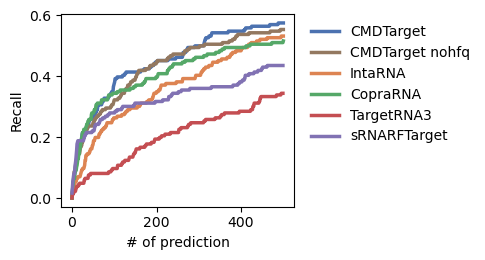

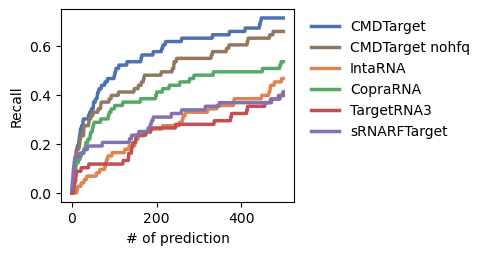

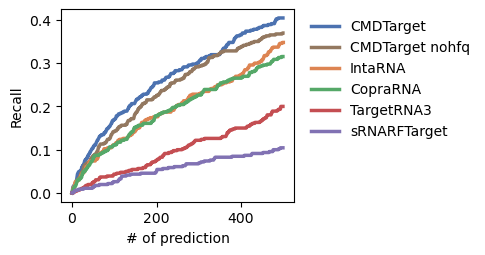

In [21]:
for genome_id in ["GCF_000005845.2","GCF_000210855.2","GCF_000742755.1"]:
    if genome_id == "GCF_000742755.1":
        validated = False
    else:
        validated = True
    used_RNA_ids = sRNA_ids_for_grid_search
    asm_id = genome_id
    fig, ax = plt.subplots(figsize=(3,2.5))
    #ax.plot([0,500],[0,1],linewidth=0.5,linestyle="--",alpha=0.5,color="gray")
    #params = "hfq.200.100--9-genomes--pair.zscore-0.7_hfq.Z-0.3_normalize-1_srm-10_nvm-10_rescale-0_reroot-1.ml"
    params = "hfq.200.100--entero9--pair.zscore-0.7_hfq.Z-0.3_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
    recalls = get_params_performance(used_RNA_ids,asm_id,params,validated=validated)
    ax.plot(recalls,label="CMDTarget",lw=2.5,color=color_lut["CMDTarget"])
    
    params = "hfq.200.100--entero9--pair.zscore-1.0_hfq.Z-0.0_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1.ml"
    recalls = get_params_performance(used_RNA_ids,asm_id,params,validated=validated)
    ax.plot(recalls,label="CMDTarget nohfq",lw=2.5,color=color_lut["CMDTarget nohfq"])
    
    
    #params = "hfq.200.100--9-genomes--pair.zscore-0.7_hfq.Z-0.3_normalize-1_srm-10_nvm-10_rescale-0_reroot-1.ml"
    intarna_recalls = get_intarna_performance(used_RNA_ids,asm_id,params,validated=validated)
    ax.plot(intarna_recalls,label="IntaRNA",lw=2.5,color=color_lut["IntaRNA"])
    
    outdir = f"../comparative-sRNA-target-prediction/output/CopraRNA/enterobacteria.9.genomes.by.genomes"
    copraRNA_recalls = get_copra_performance(used_RNA_ids,asm_id,validated=validated,outdir=outdir)
    ax.plot(copraRNA_recalls,label="CopraRNA",lw=2.5,color=color_lut["CopraRNA"])

    ax.plot(TargetRNA3_recalls[asm_id],label="TargetRNA3",lw=2.5,color=color_lut["TargetRNA3"])   
    
    ax.plot(sRNARFTarget_recalls[asm_id],label="sRNARFTarget",lw=2.5,color=color_lut["sRNARFTarget"]) 
    #plt.legend(frameon=False)
    plt.legend(loc=(1.05,0.3),frameon=False)
    ax.set_xlabel("# of prediction")
    ax.set_ylabel("Recall")